## For some actions, you may want to require human approval before running to ensure that everything is running as intended. 

In [1]:
from typing import Annotated
import operator, json
from typing import TypedDict, Annotated, Sequence
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

In [4]:
from langchain_groq import ChatGroq
llm = ChatGroq(model_name = "llama-3.1-8b-instant")

In [5]:
llm.invoke("hi")

AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 36, 'total_tokens': 44, 'completion_time': 0.010027241, 'prompt_time': 0.001630897, 'queue_time': 0.158758137, 'total_time': 0.011658138}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--6642ce7c-023b-4560-8eb0-cede6b0fa946-0', usage_metadata={'input_tokens': 36, 'output_tokens': 8, 'total_tokens': 44})

In [6]:
llm.invoke("hi").content

'How can I assist you today?'

In [7]:
@tool
def multiply(first_number: int, second_number: int) -> int:
    """Multiply two integer number."""
    return first_number * second_number

In [9]:
multiply.invoke({"first_number": 24, "second_number": 364})

8736

In [10]:
@tool
def search(query: str):
    """Perform the web search on the user query"""
    tavily = TavilySearchResults()
    result = tavily.invoke(query)
    return result

In [11]:
search("who is current president of USA?")

TypeError: 'StructuredTool' object is not callable

In [12]:
search.invoke("who is current president of USA?")

C:\Users\LOQ\AppData\Local\Temp\ipykernel_5936\897189530.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


[{'title': 'Presidents, vice presidents, and first ladies | USAGov',
  'url': 'https://www.usa.gov/presidents',
  'content': "### Current president\n\nThe 47th and current president of the United States is Donald John Trump. He was sworn into office on January 20, 2025.\n\n### Former U.S. presidents\n\nThe United States has had 45 former U.S. presidents. Read about past presidents and vice presidents.\n\nMany former presidents have presidential libraries and museums you can visit to learn about their lives and their time in office. Find presidential libraries and museums.\n\n### Requirements to be eligible to become president\n\nAccording to Article II of the U.S. Constitution, the president must:\n\nLearn about the U.S. presidential election process.\n\n## Vice president of the United States [...] ### Current first lady\n\nThe current first lady of the United States is Melania Trump.\n\n### Former first ladies\n\nFind a list of former first ladies and their presidential spouses.\n\nSe

In [13]:
tools = [search, multiply]

In [14]:
model_with_tools = llm.bind_tools(tools)

In [23]:
tool_mapping = {tool.name: tool for tool in tools}

In [24]:
tool_mapping

{'search': StructuredTool(name='search', description='Perform the web search on the user query', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000019D967C1620>),
 'multiply': StructuredTool(name='multiply', description='Multiply two integer number.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000019D84E1D940>)}

In [25]:
response = model_with_tools.invoke("What is the current president of USA?")

In [26]:
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '7tk0224sw', 'function': {'arguments': '{"query":"current president of USA"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 279, 'total_tokens': 295, 'completion_time': 0.019637487, 'prompt_time': 0.0194978, 'queue_time': 0.052784753, 'total_time': 0.039135287}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--c564d60f-36d4-493f-aa6d-8b48584383a3-0', tool_calls=[{'name': 'search', 'args': {'query': 'current president of USA'}, 'id': '7tk0224sw', 'type': 'tool_call'}], usage_metadata={'input_tokens': 279, 'output_tokens': 16, 'total_tokens': 295})

In [27]:
tool_details = response.additional_kwargs.get("tool_calls")

In [28]:
tool_details

[{'id': '7tk0224sw',
  'function': {'arguments': '{"query":"current president of USA"}',
   'name': 'search'},
  'type': 'function'}]

In [29]:
tool_details[0]["function"]["name"]

'search'

In [ ]:
# json.loads(tool_details[0]["function"]["arguments"])

{'query': 'current president of USA'}

In [33]:
tool_mapping[tool_details[0]["function"]["name"]].invoke(
    json.loads(tool_details[0]["function"]["arguments"])
)

[{'title': 'Presidents, vice presidents, and first ladies | USAGov',
  'url': 'https://www.usa.gov/presidents',
  'content': "### Current president\n\nThe 47th and current president of the United States is Donald John Trump. He was sworn into office on January 20, 2025.\n\n### Former U.S. presidents\n\nThe United States has had 45 former U.S. presidents. Read about past presidents and vice presidents.\n\nMany former presidents have presidential libraries and museums you can visit to learn about their lives and their time in office. Find presidential libraries and museums.\n\n### Requirements to be eligible to become president\n\nAccording to Article II of the U.S. Constitution, the president must:\n\nLearn about the U.S. presidential election process.\n\n## Vice president of the United States [...] ## Vice president of the United States\n\nThe vice president of the United States presides over the U.S. Senate and takes over the role of president of the United States if the president is 

In [34]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [35]:
def invoke_model(state: AgentState):
    messages = state['messages']
    question = messages[-1] # Fetching the user question
    return {"messages": [model_with_tools.invoke(question)]}

In [36]:
def invoke_tool(state: AgentState):
    tool_details = state['messages'][-1].additional_kwargs.get("tool_calls", [])[0]

    if tool_details is None:
        raise Exception("no tool call found")

    print(f'Selected tool: {tool_details.get("function").get("name")}')

    if tool_details.get("function").get("name") =="search":
        response = input(prompt=f"[y/n] continue with expensive web search?")
        if response == "n":
            raise Exception("web search discard")
        
    response = tool_mapping[tool_details['function']['name']].invoke(json.loads(tool_details.get('function', {}).get('arguments', '{}')))
    return {"messages": [response]}

In [37]:
def router(state):
    tool_calls = state['messages'][-1].additional_kwargs.get("tool_calls", [])
    if len(tool_calls):
        return "tool"
    else:
        return "end"

In [38]:
graph = StateGraph(AgentState)
graph.add_node("ai_assistant", invoke_model)
graph.add_node("tool", invoke_tool)

In [39]:
graph.add_conditional_edges("ai_assistant", router, {"tool": "tool", "end": END,})
graph.add_edge("tool", END)

graph.set_entry_point("ai_assistant")

In [40]:
app = graph.compile()

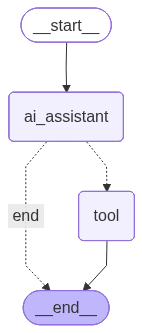

In [41]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [43]:
for s in app.stream({"messages": ["who is upcoming president of UsA?"]}):
    print(list(s.values())[0])
    print("------")

{'messages': [AIMessage(content='<brave_search>{"query": "upcoming president of USA"}', additional_kwargs={'tool_calls': [{'id': 'h2x3mjrep', 'function': {'arguments': '{"query":"upcoming president of USA"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 279, 'total_tokens': 310, 'completion_time': 0.065832464, 'prompt_time': 0.018607286, 'queue_time': 0.049221903, 'total_time': 0.08443975}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--df1222c0-edf3-4d2f-aa9e-ff59e867757e-0', tool_calls=[{'name': 'search', 'args': {'query': 'upcoming president of USA'}, 'id': 'h2x3mjrep', 'type': 'tool_call'}], usage_metadata={'input_tokens': 279, 'output_tokens': 31, 'total_tokens': 310})]}
------
Selected tool: search
{'messages': [[{'title': 'President Donald Trump [R, 2025-2029], 

In [44]:
for s in app.stream({"messages": ["what is multiplication of 23 and 46?"]}):
    print(list(s.values())[0])
    print("------")

{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'tqhs3w0vd', 'function': {'arguments': '{"first_number":23,"second_number":46}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 281, 'total_tokens': 302, 'completion_time': 0.030433905, 'prompt_time': 0.071287294, 'queue_time': 0.09155102, 'total_time': 0.101721199}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--d546781f-6d09-405d-97ed-6700ea4b1ff4-0', tool_calls=[{'name': 'multiply', 'args': {'first_number': 23, 'second_number': 46}, 'id': 'tqhs3w0vd', 'type': 'tool_call'}], usage_metadata={'input_tokens': 281, 'output_tokens': 21, 'total_tokens': 302})]}
------
Selected tool: multiply
{'messages': [1058]}
------


In [47]:
for s in app.stream({"messages": ["Who is Ricky Ponting?"]}):
    print(list(s.values())[0])
    print("------")

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=search>{"query": "Ricky Ponting"}<function=brave_search>{"query": "Ricky Ponting"}'}}

LangGraph supports human-in-the-loop workflows in a number of ways. In this section, we will use LangGraph's interrupt_before functionality to always break the tool node.

In [48]:
from langchain_groq import ChatGroq
llm = ChatGroq(model_name = "llama-3.1-8b-instant")

In [49]:
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

In [50]:
tavily = TavilySearchResults()

In [51]:
tools = [tavily]

In [52]:
llm_with_tools = llm.bind_tools(tools)

In [53]:
def ai_assistant(state: AgentState):
    return {"messages": [llm_with_tools.invoke(state['messages'])]}

In [54]:
memory = MemorySaver()

In [56]:
graph_builder = StateGraph(AgentState)
graph_builder.add_node("ai_assistant", ai_assistant)
tool_node = ToolNode(tools = tools)
graph_builder.add_node("tools", tool_node)

In [58]:
graph_builder.add_edge(START, "ai_assistant")
graph_builder.add_conditional_edges(
    "ai_assistant",
    tools_condition,
)
graph_builder.add_edge("tools", "ai_assistant")

In [59]:
app2 = graph_builder.compile(
    checkpointer = memory,
    interrupt_before = ["tools"],
    # Note: can also interrupt __after__tools, if desired
)

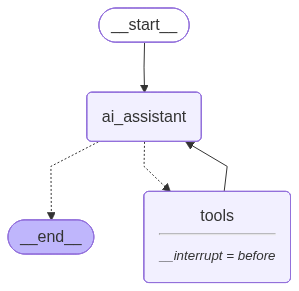

In [60]:
from IPython.display import Image, display
display(Image(app2.get_graph().draw_mermaid_png()))

In [61]:
user_input = "What is the current capital of India?"
config = {"configurable": {"thread_id": "1"}}

In [62]:
# The config is second positional argument, after the stream() or invoke()
events = app2.stream(
    {"messages": [("user", user_input)]}, config, stream_mode = "values"
    )

In [63]:
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

What is the current capital of India?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (9yk7khzz6)
 Call ID: 9yk7khzz6
  Args:
    query: current capital of India


In [64]:
# To check where process is stopped
snapshot = app2.get_state(config)

In [65]:
snapshot.next

('tools',)

In [66]:
last_message = snapshot.values['messages'][-1]

In [67]:
last_message.tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'current capital of India'},
  'id': '9yk7khzz6',
  'type': 'tool_call'}]

In [68]:
# None will append nothing new to current state, letting it resume as if it had never been interrupted
events = app2.stream(
    None, config, stream_mode = "values"
    )

In [69]:
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (9yk7khzz6)
 Call ID: 9yk7khzz6
  Args:
    query: current capital of India
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "National Capital Region (India) - Wikipedia", "url": "https://en.wikipedia.org/wiki/National_Capital_Region_(India)", "content": "The National Capital Region (NCR; Rāṣṭrīya Rājadhānī Kṣetra) is a region centred on the city of Delhi, a special union territory of India that hosts the country's capital city New Delhi. It encompasses the entirety of Delhi and a number of adjacent districts from the states of Haryana, Uttar Pradesh, and Rajasthan. The NCR and the associated National Capital Region Planning Board (NCRPB) were created in 1985 to plan the development of the region and to evolve \"harmonized policies for the control of land-uses and development of infrastruct

In [70]:
user_input = "What is the weather in India?"
config = {"configurable": {"thread_id": "1"}}

In [71]:
# None will append nothing new to current state, letting it resume as if it had never been interrupted
events = app2.stream(
    None, config, stream_mode = "values"
    )

In [74]:
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

In [75]:
app2.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='What is the current capital of India?', additional_kwargs={}, response_metadata={}, id='0f451581-68a7-4341-8cce-bc458346cc2c'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '9yk7khzz6', 'function': {'arguments': '{"query":"current capital of India"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 286, 'total_tokens': 307, 'completion_time': 0.033100299, 'prompt_time': 0.019531464, 'queue_time': 0.054723189, 'total_time': 0.052631763}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--549f6a7f-d842-4e56-852e-88153352fe23-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'current capital of India'}, 'id': '9yk7khzz6', 'type': 'tool_call'}], usage_metadata={'i